# Multi-Agent Data Quality System

This notebook implements a multi-agent pipeline for automated data quality assessment on NoiPA datasets. The system uses LangGraph for agent orchestration and Google Gemini as the underlying LLM.

The pipeline consists of the following agents, executed sequentially:
1. **Schema Validation Agent** - checks data types and column naming conventions
2. **Completeness Analysis Agent** - detects missing values, placeholders, and sparse columns
3. **Consistency Validation Agent** - verifies format uniformity, cross-column logic, and duplicates
4. **Anomaly Detection Agent** - identifies statistical outliers and rare categorical values
5. **Remediation Agent** - generates correction suggestions and computes a reliability score

## Setup and dependencies

In [1]:
%pip install -q langchain-google-genai langgraph langchain-core python-dotenv pandas numpy


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import json
import pandas as pd
import numpy as np
from typing import TypedDict, Any
from datetime import datetime
from collections import Counter
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, END

load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
assert GOOGLE_API_KEY, "GOOGLE_API_KEY not found in .env file"

llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    google_api_key=GOOGLE_API_KEY,
    temperature=0,
    max_output_tokens=4096,
)

print("Setup complete.")

Setup complete.


## Loading the dataset

We load the CSV with `dtype=str` to preserve raw values (including malformed ones) and avoid pandas auto-casting that might hide data quality issues.

In [3]:
DATASET_PATH = "data/dataset_noipa_1.csv"

df = pd.read_csv(DATASET_PATH, dtype=str)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns from {DATASET_PATH}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 51 rows x 6 columns from data/dataset_noipa_1.csv
Columns: ['Rata', 'Ente', 'Descrizione', 'Tipo_imposta', 'Imposta', 'Spesa']


,Rata,Ente,Descrizione,Tipo_imposta,Imposta,Spesa
0,202501,101,Ministero dell'Economia e delle Finanze,Erariali,IRPEF,125430.50
1,202501,102,Ministero della Salute,Previdenziali,INPS,98234.75
2,202502,103,Ministero dell'Istruzione,Erariali,IRAP,43210.00
3,202502,104,Ministero della Difesa,Varie,Addizionali Comunali,12345.60
4,202503,105,Ministero della Giustizia,Previdenziali,INAIL,8765.30


## Global state definition

The `DataQualityState` TypedDict holds all intermediate and final results. Each agent reads the shared state, runs its analysis, and writes results back into the corresponding field.

In [4]:
class DataQualityState(TypedDict):
    dataframe: Any
    dataset_path: str
    schema_results: dict
    completeness_results: dict
    completeness_overall: dict
    consistency_format: list
    consistency_cross_column: list
    consistency_duplicates: dict
    anomaly_results: dict
    remediation_results: dict
    reliability_score: float
    errors: list
    gemini_commentary: dict

## Agent 1: Schema Validation

This agent performs three checks on the dataset schema:
- Sends column metadata to Gemini to infer expected data types and allowed values
- Validates column naming conventions (snake_case, no spaces, no special characters)
- Compares inferred types against actual pandas dtypes and flags mismatches

In [5]:
def build_schema_summary(df):
    """Build a text summary of the dataframe schema to send to Gemini."""
    lines = ["Dataset schema (columns, pandas dtype, sample of 5 non-null values):"]
    for col in df.columns:
        sample = df[col].dropna().head(5).tolist()
        lines.append(f"  - '{col}': dtype={df[col].dtype}, sample={sample}")
    return "\n".join(lines)


def check_naming_conventions(columns):
    """Check that column names follow snake_case convention."""
    valid_pattern = re.compile(r'^[a-zA-Z][a-zA-Z0-9_]*$')
    snake_pattern = re.compile(r'^[a-z][a-z0-9_]*$')
    violations = []

    for col in columns:
        issues = []
        suggestions = []

        if ' ' in col:
            issues.append("contains spaces")
            suggestions.append(f"rename to '{col.replace(' ', '_').lower()}'")
        if not valid_pattern.match(col):
            issues.append("contains invalid characters")
            clean = re.sub(r'[^a-zA-Z0-9_]', '_', col).lower()
            suggestions.append(f"rename to '{clean}'")
        if valid_pattern.match(col) and not snake_pattern.match(col):
            issues.append("not snake_case")
            suggestions.append(f"rename to '{col.lower()}'")

        if issues:
            violations.append({'column': col, 'issues': issues, 'suggestions': list(set(suggestions))})

    return violations


def parse_gemini_json(raw):
    """Extract JSON object from Gemini's response (may contain extra text)."""
    try:
        start = raw.index('{')
        end = raw.rindex('}') + 1
        return json.loads(raw[start:end])
    except (ValueError, json.JSONDecodeError):
        return {}

In [6]:
def node_schema_agent(state):
    """Schema Validation Agent node."""
    print("\n" + "=" * 60)
    print("SCHEMA VALIDATION AGENT")
    print("=" * 60)

    df = state['dataframe']
    errors = list(state.get('errors', []))

    # Build schema summary and send to Gemini
    schema_summary = build_schema_summary(df)
    prompt = f"""You are a data quality expert for Italian public administration systems.
Analyze this NoiPA dataset schema and return ONLY a valid JSON object (no markdown, no backticks).

{schema_summary}

For each column return:
{{
  "<column_name>": {{
    "expected_type": "<string|integer|float|date|categorical>",
    "expected_format": "<e.g. YYYYMM, or null>",
    "allowed_values": ["<list if categorical, else []>"],
    "notes": "<brief semantic description>"
  }}
}}

Columns: {list(df.columns)}
Respond with JSON only."""

    gemini_raw = '{}'
    try:
        response = llm.invoke([HumanMessage(content=prompt)])
        gemini_raw = response.content
        print("  Gemini analysis received.")
    except Exception as e:
        errors.append(f"Schema Agent - Gemini error: {str(e)[:200]}")
        print(f"  Gemini error: {str(e)[:100]}")

    # Check naming conventions
    naming_violations = check_naming_conventions(list(df.columns))
    naming_map = {v['column']: v for v in naming_violations}
    print(f"  Found {len(naming_violations)} naming convention violations.")

    # Compile per-column results
    gemini_data = parse_gemini_json(gemini_raw)
    results = {}

    type_map = {
        'integer': ['int64', 'Int64', 'int32'],
        'float': ['float64', 'float32'],
        'string': ['object'],
        'date': ['datetime64[ns]', 'object'],
        'categorical': ['object', 'category'],
    }

    for col in df.columns:
        gem = gemini_data.get(col, {})
        expected_type = gem.get('expected_type', gem.get('tipo_atteso', 'unknown'))
        actual_type = str(df[col].dtype)
        naming_info = naming_map.get(col, {})
        null_count = int(df[col].isna().sum())
        null_pct = round(null_count / len(df) * 100, 1)

        type_issues = []
        value_issues = []
        suggestions = []

        # Type mismatch check
        compatible = type_map.get(expected_type, [])
        if compatible and actual_type not in compatible:
            if expected_type in ('integer', 'float'):
                non_numeric = df[col].dropna()
                non_numeric = non_numeric[pd.to_numeric(non_numeric, errors='coerce').isna()]
                if len(non_numeric) > 0:
                    type_issues.append(f"Expected '{expected_type}' but found '{actual_type}', {len(non_numeric)} non-numeric values")
                    value_issues.extend(non_numeric.head(3).tolist())

        # Format check (YYYYMM)
        fmt = gem.get('expected_format', gem.get('formato_atteso'))
        if fmt and 'YYYYMM' in str(fmt).upper():
            bad = df[col].dropna()
            bad = bad[~bad.astype(str).str.match(r'^\d{6}$')]
            if len(bad) > 0:
                type_issues.append(f"Expected YYYYMM format, found {len(bad)} non-conforming values")
                value_issues.extend(bad.head(3).tolist())

        # Allowed values check
        allowed = gem.get('allowed_values', gem.get('valori_ammessi', []))
        if allowed:
            invalid = df[col].dropna()
            invalid = invalid[~invalid.astype(str).isin([str(v) for v in allowed])]
            if len(invalid) > 0:
                value_issues.extend(invalid.unique().tolist()[:5])

        if naming_info:
            suggestions.extend(naming_info.get('suggestions', []))
        if null_count > 0:
            suggestions.append(f"Column has {null_count} nulls ({null_pct}%)")

        has_issues = bool(type_issues or value_issues or naming_info)
        results[col] = {
            'expected_type': expected_type,
            'actual_type': actual_type,
            'null_count': null_count,
            'null_pct': null_pct,
            'naming_issues': naming_info.get('issues', []),
            'type_issues': type_issues,
            'value_issues': list(set(str(v) for v in value_issues)),
            'suggestions': suggestions,
            'status': 'FAIL' if has_issues else 'OK'
        }

    n_fail = sum(1 for v in results.values() if v['status'] == 'FAIL')
    print(f"  Result: {n_fail}/{len(results)} columns with issues.")

    return {'schema_results': results, 'errors': errors}

## Agent 2: Completeness Analysis

This agent scans the dataset for missing data. Beyond standard NaN values, it also detects common placeholder strings like "N/A", "-", "unknown", etc. that are semantically equivalent to missing data but wouldn't be caught by `isna()`. It then computes completeness rates per column and flags sparse columns.

In [7]:
PLACEHOLDER_VALUES = {
    'n/a', 'na', 'n.a.', 'n.d.', 'nd', 'nan', 'none', 'null',
    '-', '--', '---', '', ' ', 'unknown', 'sconosciuto',
    'missing', 'vuoto', 'dato mancante', 'non disponibile'
}


def detect_missing_values(df):
    """Detect native nulls and placeholder values for each column."""
    results = {}
    for col in df.columns:
        null_mask = df[col].isna()
        null_count = int(null_mask.sum())
        null_rows = df.index[null_mask].tolist()

        # Detect placeholders (values that look like missing data)
        ph_mask = df[col].astype(str).str.strip().str.lower().isin(PLACEHOLDER_VALUES) & ~null_mask
        ph_count = int(ph_mask.sum())
        ph_rows = df.index[ph_mask].tolist()
        ph_values = df.loc[ph_mask, col].unique().tolist()

        total_missing = null_count + ph_count
        completeness = round((1 - total_missing / len(df)) * 100, 2)

        results[col] = {
            'null_count': null_count,
            'null_rows': null_rows[:20],
            'placeholder_count': ph_count,
            'placeholder_rows': ph_rows[:20],
            'placeholder_values_found': ph_values,
            'total_missing': total_missing,
            'total_rows': len(df),
            'completeness_pct': completeness,
            'is_sparse': completeness < 30
        }
    return results


def compute_overall_completeness(col_results):
    """Aggregate completeness stats across all columns."""
    total_cells = sum(s['total_rows'] for s in col_results.values())
    total_missing = sum(s['total_missing'] for s in col_results.values())

    sparse = [
        {'column': c, 'completeness_pct': s['completeness_pct']}
        for c, s in col_results.items() if s['is_sparse']
    ]

    worst = sorted(
        [(c, s['total_missing'], s['completeness_pct']) for c, s in col_results.items() if s['total_missing'] > 0],
        key=lambda x: x[1], reverse=True
    )[:5]

    return {
        'overall_completeness_pct': round((1 - total_missing / total_cells) * 100, 2) if total_cells else 100.0,
        'total_cells': total_cells,
        'total_missing': total_missing,
        'sparse_columns': sparse,
        'worst_columns': [{'column': c, 'missing': m, 'completeness_pct': p} for c, m, p in worst]
    }

In [8]:
def node_completeness_agent(state):
    """Completeness Analysis Agent node."""
    print("\n" + "=" * 60)
    print("COMPLETENESS ANALYSIS AGENT")
    print("=" * 60)

    df = state['dataframe']
    errors = list(state.get('errors', []))
    commentary = dict(state.get('gemini_commentary', {}))

    try:
        per_col = detect_missing_values(df)
        overall = compute_overall_completeness(per_col)

        print(f"  Overall completeness: {overall['overall_completeness_pct']}%")
        print(f"  Total missing cells: {overall['total_missing']}/{overall['total_cells']}")
        if overall['sparse_columns']:
            print(f"  Sparse columns detected: {[s['column'] for s in overall['sparse_columns']]}")

        # Ask Gemini for a brief commentary
        try:
            summary = json.dumps({
                'overall': overall['overall_completeness_pct'],
                'missing': overall['total_missing'],
                'sparse': [s['column'] for s in overall['sparse_columns']],
                'worst': overall['worst_columns']
            }, ensure_ascii=False)
            resp = llm.invoke([HumanMessage(content=f"You are a data quality expert. Briefly comment (2-3 sentences, English) on these completeness results for a NoiPA dataset:\n{summary}")])
            commentary['completeness'] = resp.content
        except Exception as e:
            commentary['completeness'] = 'Commentary not available.'
            errors.append(f"Completeness - Gemini commentary error: {str(e)[:200]}")

    except Exception as e:
        per_col, overall = {}, {}
        errors.append(f"Completeness Agent error: {str(e)[:200]}")

    return {
        'completeness_results': per_col,
        'completeness_overall': overall,
        'errors': errors,
        'gemini_commentary': commentary
    }

## Agent 3: Consistency Validation

This agent checks three aspects of data consistency:

- **Format consistency**: detects mixed formats within the same column (e.g., `202501` vs `2025-01` in the Rata column)
- **Cross-column logic**: validates that `Tipo_imposta` and `Imposta` values are coherent (e.g., "Erariali" should map to IRPEF/IRAP/Addizionali, not INPS)
- **Duplicate detection**: finds exact duplicates and near-duplicates (rows differing in only one column)

In [9]:
def check_format_consistency(df):
    """Detect mixed value formats within each column."""
    violations = []
    for col in df.columns:
        values = df[col].dropna().astype(str).str.strip()
        if len(values) == 0:
            continue

        # Classify each value's format
        patterns = {}
        for val in values:
            if re.match(r'^\d{6}$', val):
                p = 'YYYYMM'
            elif re.match(r'^\d{4}-\d{2}$', val):
                p = 'YYYY-MM'
            elif re.match(r'^\d{4}/\d{2}$', val):
                p = 'YYYY/MM'
            elif re.match(r'^-?\d+\.\d+$', val):
                p = 'decimal'
            elif re.match(r'^-?\d+$', val):
                p = 'integer'
            elif val.lower() in PLACEHOLDER_VALUES:
                p = 'placeholder'
            else:
                p = 'text'
            patterns[p] = patterns.get(p, 0) + 1

        real = {k: v for k, v in patterns.items() if k != 'placeholder'}
        if len(real) > 1:
            dominant = max(real, key=real.get)
            dominant_pct = round(real[dominant] / sum(real.values()) * 100, 1)
            minority = {k: v for k, v in real.items() if k != dominant}
            violations.append({
                'column': col,
                'type': 'mixed_format',
                'detail': f"Mixed formats: {real}",
                'dominant_format': dominant,
                'dominant_pct': dominant_pct,
                'minority_formats': minority,
                'suggestion': f"Standardize '{col}' to '{dominant}' format ({dominant_pct}% of values)"
            })
    return violations


def check_cross_column_consistency(df):
    """Validate logical relationships between Tipo_imposta and Imposta."""
    violations = []

    # Business rules for NoiPA
    rules = {
        'Erariali': {'IRPEF', 'IRAP', 'Addizionali Comunali', 'Addizionali Regionali'},
        'Previdenziali': {'INPS', 'INAIL'},
    }

    if 'Tipo_imposta' in df.columns and 'Imposta' in df.columns:
        for idx, row in df.iterrows():
            tipo = str(row.get('Tipo_imposta', '')).strip()
            imposta = str(row.get('Imposta', '')).strip()

            if tipo.lower() in PLACEHOLDER_VALUES or imposta.lower() in PLACEHOLDER_VALUES:
                continue
            if pd.isna(row.get('Tipo_imposta')) or pd.isna(row.get('Imposta')):
                continue

            allowed = rules.get(tipo)
            if allowed and imposta not in allowed:
                violations.append({
                    'column': 'Tipo_imposta <> Imposta',
                    'type': 'cross_column',
                    'row': int(idx),
                    'detail': f"Row {idx}: Tipo_imposta='{tipo}' but Imposta='{imposta}' (expected: {allowed})",
                    'suggestion': f"Row {idx}: verify if '{imposta}' is correct for '{tipo}'"
                })

    # Also check for typos in Tipo_imposta
    if 'Tipo_imposta' in df.columns:
        expected_values = {'Erariali', 'Previdenziali', 'Varie'}
        for idx, row in df.iterrows():
            tipo = str(row.get('Tipo_imposta', '')).strip()
            if pd.isna(row.get('Tipo_imposta')) or tipo.lower() in PLACEHOLDER_VALUES:
                continue
            if tipo not in expected_values:
                violations.append({
                    'column': 'Tipo_imposta',
                    'type': 'unexpected_value',
                    'row': int(idx),
                    'detail': f"Row {idx}: '{tipo}' is not in expected values {expected_values}",
                    'suggestion': f"Row {idx}: possible typo in '{tipo}'"
                })

    return violations


def detect_duplicates(df):
    """Find exact and near-duplicate rows."""
    # Exact duplicates
    exact_mask = df.duplicated(keep=False)
    exact_groups = []
    if exact_mask.sum() > 0:
        for _, group in df[exact_mask].groupby(list(df.columns)):
            if len(group) > 1:
                exact_groups.append({'rows': group.index.tolist(), 'values': group.iloc[0].to_dict()})

    # Near-duplicates (differ by exactly 1 column)
    near_dups = []
    sample = df.head(200) if len(df) > 200 else df
    for i in range(len(sample)):
        for j in range(i + 1, len(sample)):
            diff = (sample.iloc[i].astype(str) != sample.iloc[j].astype(str))
            if diff.sum() == 1:
                col_diff = diff[diff].index[0]
                near_dups.append({
                    'row_a': int(sample.index[i]),
                    'row_b': int(sample.index[j]),
                    'differing_column': col_diff,
                    'value_a': str(sample.iloc[i][col_diff]),
                    'value_b': str(sample.iloc[j][col_diff])
                })

    return {
        'exact_duplicates': {'count': len(exact_groups), 'total_rows': int(exact_mask.sum()), 'groups': exact_groups[:10]},
        'near_duplicates': {'count': len(near_dups), 'pairs': near_dups[:10]}
    }

In [10]:
def node_consistency_agent(state):
    """Consistency Validation Agent node."""
    print("\n" + "=" * 60)
    print("CONSISTENCY VALIDATION AGENT")
    print("=" * 60)

    df = state['dataframe']
    errors = list(state.get('errors', []))
    commentary = dict(state.get('gemini_commentary', {}))

    try:
        fmt_issues = check_format_consistency(df)
        cross_issues = check_cross_column_consistency(df)
        dup_results = detect_duplicates(df)

        print(f"  Format issues: {len(fmt_issues)}")
        print(f"  Cross-column violations: {len(cross_issues)}")
        print(f"  Exact duplicate groups: {dup_results['exact_duplicates']['count']}")
        print(f"  Near-duplicate pairs: {dup_results['near_duplicates']['count']}")

        try:
            summary = f"Format issues: {len(fmt_issues)}, cross-column violations: {len(cross_issues)}, exact duplicates: {dup_results['exact_duplicates']['count']}, near-duplicates: {dup_results['near_duplicates']['count']}"
            resp = llm.invoke([HumanMessage(content=f"You are a data quality expert. Briefly comment (2-3 sentences, English) on these consistency results for a NoiPA dataset:\n{summary}")])
            commentary['consistency'] = resp.content
        except Exception as e:
            commentary['consistency'] = 'Commentary not available.'
            errors.append(f"Consistency - Gemini commentary error: {str(e)[:200]}")

    except Exception as e:
        fmt_issues, cross_issues = [], []
        dup_results = {'exact_duplicates': {'count': 0, 'total_rows': 0, 'groups': []}, 'near_duplicates': {'count': 0, 'pairs': []}}
        errors.append(f"Consistency Agent error: {str(e)[:200]}")

    return {
        'consistency_format': fmt_issues,
        'consistency_cross_column': cross_issues,
        'consistency_duplicates': dup_results,
        'errors': errors,
        'gemini_commentary': commentary
    }

## Agent 4: Anomaly Detection & Agent 5: Remediation

Agent 4 detects numerical outliers (Z-score and IQR) and rare categorical values that may indicate typos.
Agent 5 collects all findings, calculates a reliability score (0-100), and uses Gemini to generate specific correction suggestions.

In [11]:
def detect_numerical_outliers(df, column):
    """Find outliers using Z-score and IQR methods."""
    outliers = []
    numeric_vals = pd.to_numeric(df[column], errors='coerce').dropna()

    if len(numeric_vals) < 3:
        return outliers

    mean = numeric_vals.mean()
    std = numeric_vals.std()
    q1 = numeric_vals.quantile(0.25)
    q3 = numeric_vals.quantile(0.75)
    iqr = q3 - q1
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr

    for idx, value in numeric_vals.items():
        reasons = []
        if std > 0:
            z = (value - mean) / std
            if abs(z) > 3:
                reasons.append(f'Z-score = {z:.2f} (threshold: |z| > 3)')
        if value < iqr_lower:
            reasons.append(f'Below IQR lower bound ({iqr_lower:.2f})')
        elif value > iqr_upper:
            reasons.append(f'Above IQR upper bound ({iqr_upper:.2f})')

        if reasons:
            outliers.append({
                'row': int(idx),
                'column': column,
                'value': float(value),
                'reasons': reasons,
                'stats': {'mean': round(mean, 2), 'std': round(std, 2),
                          'q1': round(q1, 2), 'q3': round(q3, 2), 'iqr': round(iqr, 2)},
            })
    return outliers


def detect_rare_categories(df, column, min_frequency=2):
    """Find categorical values that appear fewer than min_frequency times."""
    rare_values = []
    values = df[column].dropna().astype(str).str.strip()
    if values.empty:
        return rare_values

    counts = values.value_counts()
    for value, count in counts.items():
        if count < min_frequency and value.lower() not in PLACEHOLDER_VALUES:
            rare_values.append({
                'column': column,
                'value': value,
                'count': int(count),
                'total_rows': len(values),
                'rows': df.index[df[column].astype(str).str.strip() == value].tolist(),
                'message': f"Column '{column}': value '{value}' appears only {count} time(s) -- possible typo",
            })
    return rare_values


def node_anomaly_agent(state):
    """Anomaly Detection Agent node."""
    print('\n' + '=' * 60)
    print('ANOMALY DETECTION AGENT')
    print('=' * 60)

    df = state['dataframe']
    errors = list(state.get('errors', []))
    commentary = dict(state.get('gemini_commentary', {}))

    try:
        all_outliers = []
        all_rare = []
        column_stats = {}

        for col in df.columns:
            numeric_check = pd.to_numeric(df[col], errors='coerce')
            non_null_numeric = numeric_check.dropna()
            non_null_total = df[col].dropna()

            if len(non_null_total) > 0 and len(non_null_numeric) / len(non_null_total) > 0.5:
                outliers = detect_numerical_outliers(df, col)
                all_outliers.extend(outliers)
                if len(non_null_numeric) > 0:
                    column_stats[col] = {
                        'type': 'numerical',
                        'mean': round(non_null_numeric.mean(), 2),
                        'std': round(non_null_numeric.std(), 2),
                        'min': round(non_null_numeric.min(), 2),
                        'max': round(non_null_numeric.max(), 2),
                        'outlier_count': len(outliers),
                    }
            else:
                rare = detect_rare_categories(df, col)
                all_rare.extend(rare)
                value_counts = df[col].dropna().astype(str).value_counts()
                column_stats[col] = {
                    'type': 'categorical',
                    'unique_values': int(value_counts.nunique()),
                    'most_common': value_counts.index[0] if len(value_counts) > 0 else None,
                    'rare_count': len(rare),
                }

        anomaly_results = {
            'outliers': all_outliers,
            'rare_categories': all_rare,
            'column_stats': column_stats,
            'summary': {
                'total_outliers': len(all_outliers),
                'total_rare_categories': len(all_rare),
                'columns_analyzed': len(df.columns),
            },
        }

        print(f'  Numerical outliers: {len(all_outliers)}')
        for o in all_outliers:
            print(f"    Row {o['row']}, {o['column']}: {o['value']} ({', '.join(o['reasons'])})")
        print(f'  Rare categorical values: {len(all_rare)}')
        for r in all_rare:
            print(f"    {r['message']}")

        # Gemini commentary
        try:
            summary_text = f'Outliers: {len(all_outliers)}, Rare categories: {len(all_rare)}. '
            for o in all_outliers[:5]:
                summary_text += f"Row {o['row']} col {o['column']}={o['value']}; "
            resp = llm.invoke([HumanMessage(content=f'You are a data quality expert. Briefly comment (2-3 sentences, English) on these anomaly detection results for a NoiPA dataset:\n{summary_text}')])
            commentary['anomaly'] = resp.content
        except Exception as e:
            commentary['anomaly'] = 'Commentary not available.'
            errors.append(f'Anomaly - Gemini commentary error: {str(e)[:200]}')

    except Exception as e:
        anomaly_results = {}
        errors.append(f'Anomaly Agent error: {str(e)[:200]}')

    return {
        'anomaly_results': anomaly_results,
        'errors': errors,
        'gemini_commentary': commentary,
    }

In [12]:

def calculate_reliability_score(state):
    """Calculate overall reliability score (0-100) as weighted average."""
    scores = {}
    df = state.get('dataframe', pd.DataFrame())
    total_rows = len(df)
    total_columns = len(df.columns)

    # Completeness (40%)
    comp_overall = state.get('completeness_overall', {})
    scores['completeness'] = comp_overall.get('overall_completeness_pct', 100.0)

    # Schema (30%)
    sr = state.get('schema_results', {})
    n_fail = sum(1 for v in sr.values() if v.get('status') == 'FAIL')
    if total_columns > 0:
        scores['schema'] = round(max(0, (total_columns - n_fail) / total_columns) * 100, 2)
    else:
        scores['schema'] = 100.0

    # Consistency (20%)
    fmt_count = len(state.get('consistency_format', []))
    cross_count = len(state.get('consistency_cross_column', []))
    dup_count = state.get('consistency_duplicates', {}).get('exact_duplicates', {}).get('count', 0)
    total_cons_issues = fmt_count + cross_count + dup_count
    if total_rows > 0:
        scores['consistency'] = round(max(0, (total_rows - total_cons_issues) / total_rows) * 100, 2)
    else:
        scores['consistency'] = 100.0

    # Anomaly (10%)
    anom = state.get('anomaly_results', {})
    anom_summary = anom.get('summary', {})
    total_anomalies = anom_summary.get('total_outliers', 0) + anom_summary.get('total_rare_categories', 0)
    if total_rows > 0:
        scores['anomaly'] = round(max(0, (total_rows - total_anomalies) / total_rows) * 100, 2)
    else:
        scores['anomaly'] = 100.0

    # Weighted average
    scores['overall'] = round(
        scores['completeness'] * 0.40
        + scores['schema'] * 0.30
        + scores['consistency'] * 0.20
        + scores['anomaly'] * 0.10, 2)

    return scores


def build_remediation_prompt(state):
    """Build a prompt summarizing all findings for Gemini."""
    parts = [
        'You are a data quality expert. Below are all findings from a '
        'data quality audit of an Italian public administration (NoiPA) dataset. '
        'For each problem, suggest a SPECIFIC remediation action.\n\n'
    ]

    # Schema
    sr = state.get('schema_results', {})
    fails = {col: info for col, info in sr.items() if info.get('status') == 'FAIL'}
    if fails:
        parts.append('SCHEMA ISSUES:\n')
        for col, info in list(fails.items())[:10]:
            issues = info.get('naming_issues', []) + info.get('type_issues', [])
            parts.append(f"- Column '{col}': {issues}\n")
        parts.append('\n')

    # Completeness
    comp = state.get('completeness_overall', {})
    if comp:
        parts.append(
            f"COMPLETENESS: {comp.get('overall_completeness_pct', 'N/A')}% complete. "
            f"{comp.get('total_missing', 0)} missing cells out of {comp.get('total_cells', 0)}.\n"
        )
        for s in comp.get('sparse_columns', []):
            parts.append(f"- Sparse column: '{s['column']}' ({s.get('missing_pct', '?')}% missing)\n")
        parts.append('\n')

    # Consistency
    fmt = state.get('consistency_format', [])
    if fmt:
        parts.append('FORMAT ISSUES:\n')
        for f in fmt[:10]:
            parts.append(f"- {f.get('detail', str(f))}\n")
        parts.append('\n')

    cross = state.get('consistency_cross_column', [])
    if cross:
        parts.append('CROSS-COLUMN ISSUES:\n')
        for c in cross[:10]:
            parts.append(f"- {c.get('detail', str(c))}\n")
        parts.append('\n')

    dups = state.get('consistency_duplicates', {})
    exact = dups.get('exact_duplicates', {})
    if exact.get('count', 0) > 0:
        parts.append(f"DUPLICATES: {exact['count']} groups of identical rows.\n")
        for g in exact.get('groups', [])[:5]:
            parts.append(f"- Rows {g['rows']} are identical\n")
        parts.append('\n')

    # Anomalies
    anom = state.get('anomaly_results', {})
    if anom.get('outliers'):
        parts.append('NUMERICAL OUTLIERS:\n')
        for o in anom['outliers'][:10]:
            parts.append(
                f"- Row {o['row']}, column '{o['column']}': value {o['value']} "
                f"({', '.join(o['reasons'])})\n"
            )
        parts.append('\n')

    if anom.get('rare_categories'):
        parts.append('RARE CATEGORIES:\n')
        for r in anom['rare_categories'][:10]:
            parts.append(f"- {r['message']}\n")
        parts.append('\n')

    parts.append(
        'For each problem, provide:\n'
        '1. The specific row and column\n'
        '2. A concrete remediation action\n'
        '3. Priority: HIGH, MEDIUM, or LOW\n\n'
        'End with a brief overall assessment of the dataset quality.'
    )
    return ''.join(parts)


def node_remediation_agent(state):
    """Remediation Agent node."""
    print('\n' + '=' * 60)
    print('REMEDIATION AGENT')
    print('=' * 60)

    errors = list(state.get('errors', []))
    commentary = dict(state.get('gemini_commentary', {}))

    # Step 1: Calculate reliability score
    scores = calculate_reliability_score(state)
    print(f'  Reliability Score: {scores["overall"]} / 100')
    print(f'    Completeness (40%): {scores["completeness"]}')
    print(f'    Schema (30%):       {scores["schema"]}')
    print(f'    Consistency (20%):  {scores["consistency"]}')
    print(f'    Anomaly (10%):      {scores["anomaly"]}')

    # Step 2: Call Gemini for remediation suggestions
    prompt = build_remediation_prompt(state)
    gemini_suggestions = None

    try:
        resp = llm.invoke([HumanMessage(content=prompt)])
        gemini_suggestions = resp.content
        print('  Gemini generated remediation suggestions.')
    except Exception as e:
        gemini_suggestions = f'Suggestions not available: {str(e)[:200]}'
        errors.append(f'Remediation - Gemini error: {str(e)[:200]}')
        print(f'  WARNING: Gemini call failed: {str(e)[:100]}')

    remediation_results = {
        'reliability_scores': scores,
        'gemini_suggestions': gemini_suggestions,
    }

    commentary['remediation'] = gemini_suggestions or 'Not available.'

    return {
        'remediation_results': remediation_results,
        'reliability_score': scores['overall'],
        'errors': errors,
        'gemini_commentary': commentary,
    }

## Pipeline orchestration

We use LangGraph's `StateGraph` to connect all agents in a sequential pipeline. Each node reads from and writes to a shared typed state.

In [13]:
builder = StateGraph(DataQualityState)

builder.add_node('schema_agent',       node_schema_agent)
builder.add_node('completeness_agent', node_completeness_agent)
builder.add_node('consistency_agent',  node_consistency_agent)
builder.add_node('anomaly_agent',      node_anomaly_agent)
builder.add_node('remediation_agent',  node_remediation_agent)

builder.set_entry_point('schema_agent')
builder.add_edge('schema_agent',       'completeness_agent')
builder.add_edge('completeness_agent', 'consistency_agent')
builder.add_edge('consistency_agent',  'anomaly_agent')
builder.add_edge('anomaly_agent',      'remediation_agent')
builder.add_edge('remediation_agent',  END)

pipeline = builder.compile()
print("Pipeline compiled: 5 agents in sequence.")

Pipeline compiled: 5 agents in sequence.


## Running the pipeline

In [14]:
initial_state = {
    'dataframe': df,
    'dataset_path': DATASET_PATH,
    'schema_results': {},
    'completeness_results': {},
    'completeness_overall': {},
    'consistency_format': [],
    'consistency_cross_column': [],
    'consistency_duplicates': {},
    'anomaly_results': {},
    'remediation_results': {},
    'reliability_score': 0.0,
    'errors': [],
    'gemini_commentary': {},
}

print(f"Running pipeline on {DATASET_PATH} ({df.shape[0]} rows x {df.shape[1]} cols)")
final_state = pipeline.invoke(initial_state)

print("\n" + "=" * 60)
print("PIPELINE COMPLETE")
print("=" * 60)
if final_state['errors']:
    print(f"\nWarnings/errors ({len(final_state['errors'])}):\n")
    for e in final_state['errors']:
        print(f"  - {e[:150]}")

Running pipeline on data/dataset_noipa_1.csv (51 rows x 6 cols)

SCHEMA VALIDATION AGENT
  Gemini error: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'cod
  Found 6 naming convention violations.
  Result: 6/6 columns with issues.

COMPLETENESS ANALYSIS AGENT
  Overall completeness: 99.02%
  Total missing cells: 3/306

CONSISTENCY VALIDATION AGENT
  Format issues: 1
  Cross-column violations: 2
  Exact duplicate groups: 2
  Near-duplicate pairs: 1

ANOMALY DETECTION AGENT
  Numerical outliers: 2
    Row 22, Spesa: 999999999.0 (Z-score = 4.90 (threshold: |z| > 3), Above IQR upper bound (219763.44))
    Row 44, Spesa: 999999999.0 (Z-score = 4.90 (threshold: |z| > 3), Above IQR upper bound (219763.44))
  Rare categorical values: 1
    Column 'Tipo_imposta': value 'Erarali' appears only 1 time(s) -- possible typo

REMEDIATION AGENT
  Reliability Score: 67.06 / 100
    Completeness (40%): 99.02
    Schema (30%):       0
    Consistency (20%)

## Summary report

Below we print a consolidated view of all findings from the pipeline. The output includes per-column schema issues, completeness stats, consistency violations, and (when implemented) anomaly and remediation results.

In [15]:
print("=" * 70)
print("DATA QUALITY REPORT")
print("=" * 70)

# Schema results
sr = final_state.get('schema_results', {})
n_fail = sum(1 for v in sr.values() if v.get('status') == 'FAIL')
print(f"\n--- Schema Validation ---")
print(f"Columns analyzed: {len(sr)}, with issues: {n_fail}")
for col, info in sr.items():
    if info['status'] == 'FAIL':
        print(f"  {col}: {info['naming_issues'] + info['type_issues']}")

# Completeness results
co = final_state.get('completeness_overall', {})
print(f"\n--- Completeness Analysis ---")
print(f"Overall completeness: {co.get('overall_completeness_pct', 'N/A')}%")
print(f"Missing cells: {co.get('total_missing', 'N/A')}/{co.get('total_cells', 'N/A')}")
if co.get('sparse_columns'):
    print(f"Sparse columns: {[s['column'] for s in co['sparse_columns']]}")
gc = final_state.get('gemini_commentary', {})
if gc.get('completeness'):
    print(f"Gemini: {gc['completeness'][:250]}")

# Consistency results
fmt = final_state.get('consistency_format', [])
cross = final_state.get('consistency_cross_column', [])
dups = final_state.get('consistency_duplicates', {})
print(f"\n--- Consistency Validation ---")
print(f"Format issues: {len(fmt)}")
for f in fmt:
    print(f"  {f['column']}: {f['detail']}")
print(f"Cross-column violations: {len(cross)}")
for c in cross[:5]:
    print(f"  {c['detail']}")
if len(cross) > 5:
    print(f"  ... and {len(cross)-5} more")
print(f"Exact duplicates: {dups.get('exact_duplicates', {}).get('count', 0)} groups")
for g in dups.get('exact_duplicates', {}).get('groups', []):
    print(f"  Rows {g['rows']} are identical")
print(f"Near-duplicates: {dups.get('near_duplicates', {}).get('count', 0)} pairs")
for p in dups.get('near_duplicates', {}).get('pairs', [])[:3]:
    print(f"  Rows {p['row_a']}, {p['row_b']} differ only in '{p['differing_column']}'")
if gc.get('consistency'):
    print(f"Gemini: {gc['consistency'][:250]}")

# Anomaly Detection results
anom = final_state.get('anomaly_results', {})
anom_s = anom.get('summary', {})
print(f"\n--- Anomaly Detection ---")
print(f"Numerical outliers: {anom_s.get('total_outliers', 0)}")
for o in anom.get('outliers', [])[:10]:
    print(f"  Row {o['row']}, {o['column']}: {o['value']} ({', '.join(o['reasons'])})")
print(f"Rare categorical values: {anom_s.get('total_rare_categories', 0)}")
for r in anom.get('rare_categories', [])[:10]:
    print(f"  {r['message']}")
if gc.get('anomaly'):
    print(f"Gemini: {gc['anomaly'][:250]}")

# Remediation results
rem = final_state.get('remediation_results', {})
rem_scores = rem.get('reliability_scores', {})
print(f"\n--- Remediation ---")
print(f"Reliability Score: {final_state.get('reliability_score', 0.0)}/100")
if rem_scores:
    print(f"  Completeness (40%): {rem_scores.get('completeness', 'N/A')}")
    print(f"  Schema (30%):       {rem_scores.get('schema', 'N/A')}")
    print(f"  Consistency (20%):  {rem_scores.get('consistency', 'N/A')}")
    print(f"  Anomaly (10%):      {rem_scores.get('anomaly', 'N/A')}")
suggestions = rem.get('gemini_suggestions', '')
if suggestions:
    print(f"\nGemini Remediation Suggestions:")
    print(suggestions[:2000])

print("\n" + "=" * 70)


DATA QUALITY REPORT

--- Schema Validation ---
Columns analyzed: 6, with issues: 6
  Rata: ['not snake_case']
  Ente: ['not snake_case']
  Descrizione: ['not snake_case']
  Tipo_imposta: ['not snake_case']
  Imposta: ['not snake_case']
  Spesa: ['not snake_case']

--- Completeness Analysis ---
Overall completeness: 99.02%
Missing cells: 3/306
Gemini: Commentary not available.

--- Consistency Validation ---
Format issues: 1
  Rata: Mixed formats: {'YYYYMM': 49, 'YYYY-MM': 2}
Cross-column violations: 2
  Row 23: Tipo_imposta='Erariali' but Imposta='INPS' (expected: {'Addizionali Comunali', 'IRPEF', 'IRAP', 'Addizionali Regionali'})
  Row 39: 'Erarali' is not in expected values {'Erariali', 'Varie', 'Previdenziali'}
Exact duplicates: 2 groups
  Rows [1, 49] are identical
  Rows [47, 48] are identical
Near-duplicates: 1 pairs
  Rows 22, 44 differ only in 'Rata'
Gemini: Commentary not available.

--- Anomaly Detection ---
Numerical outliers: 2
  Row 22, Spesa: 999999999.0 (Z-score = 4.90 (

## Export results to JSON

In [16]:
report = {
    'pipeline': 'Multi-Agent Data Quality',
    'dataset': DATASET_PATH,
    'timestamp': datetime.now().isoformat(),
    'rows': len(df),
    'columns': len(df.columns),
    'schema_results': final_state.get('schema_results', {}),
    'completeness_overall': final_state.get('completeness_overall', {}),
    'consistency_format_count': len(final_state.get('consistency_format', [])),
    'consistency_cross_column_count': len(final_state.get('consistency_cross_column', [])),
    'consistency_duplicates': final_state.get('consistency_duplicates', {}),
    'reliability_score': final_state.get('reliability_score', 0.0),
    'gemini_commentary': final_state.get('gemini_commentary', {}),
    'errors': final_state.get('errors', []),
}

output_path = 'data/data_quality_report.json'
os.makedirs('data', exist_ok=True)
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2, default=str)

print(f"Report saved to {output_path}")

Report saved to data/data_quality_report.json


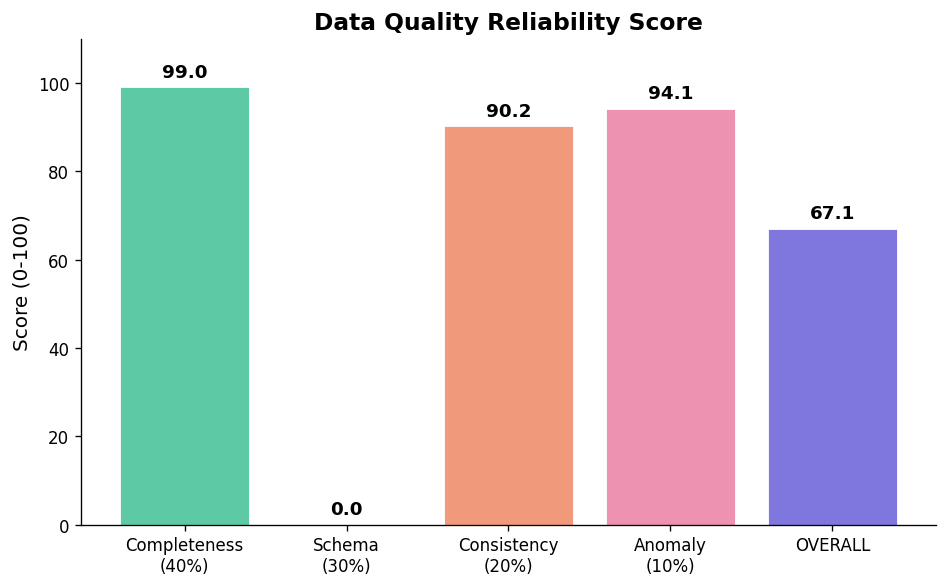

Saved: images/reliability_score.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
os.makedirs('images', exist_ok=True)

# Extract scores from final state
rem = final_state.get('remediation_results', {})
scores = rem.get('reliability_scores', {})

if scores:
    # --- Chart 1: Reliability Score Breakdown ---
    fig, ax = plt.subplots(figsize=(8, 5))
    categories = ['Completeness\n(40%)', 'Schema\n(30%)', 'Consistency\n(20%)',
                  'Anomaly\n(10%)', 'OVERALL']
    values = [scores['completeness'], scores['schema'],
              scores['consistency'], scores['anomaly'], scores['overall']]
    colors = ['#5DCAA5', '#85B7EB', '#F0997B', '#ED93B1', '#7F77DD']

    bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylim(0, 110)
    ax.set_ylabel('Score (0-100)', fontsize=12)
    ax.set_title('Data Quality Reliability Score', fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('images/reliability_score.png', bbox_inches='tight')
    plt.show()
    print('Saved: images/reliability_score.png')
else:
    print('No reliability scores available. Run the pipeline first.')

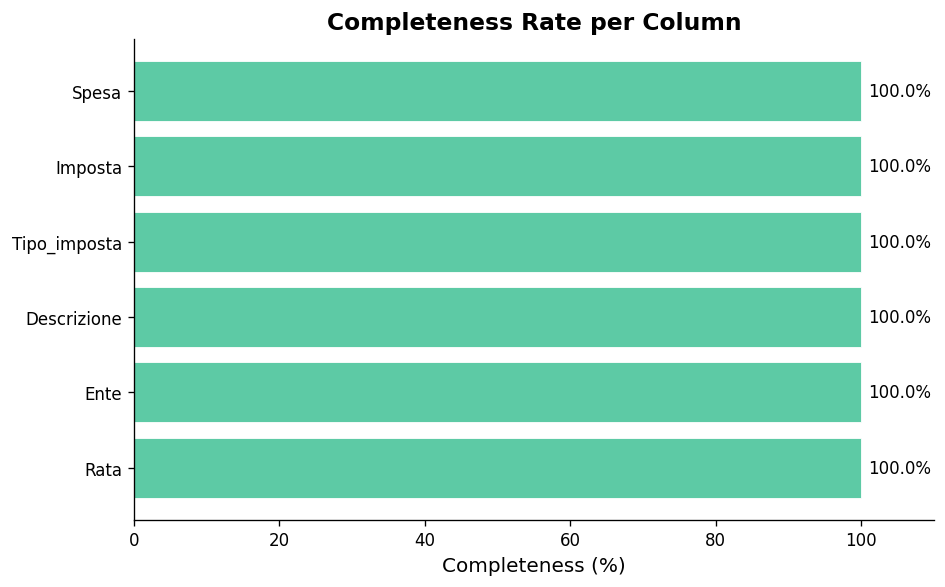

Saved: images/completeness_per_column.png

ISSUE SUMMARY TABLE
           Category  Count Severity
      Schema Issues      6     HIGH
     Missing Values      3   MEDIUM
      Format Issues      1   MEDIUM
Cross-Column Issues      2   MEDIUM
         Duplicates      2   MEDIUM
 Numerical Outliers      2   MEDIUM
    Rare Categories      1   MEDIUM

Total issues: 17
Reliability Score: 67.06/100

GEMINI REMEDIATION SUGGESTIONS
Suggestions not available: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. Fo


In [18]:
# --- Completeness per column chart ---
comp_results = final_state.get('completeness_results', {})
if comp_results:
    fig, ax = plt.subplots(figsize=(8, 5))
    columns = list(comp_results.keys())
    rates = []
    for col in columns:
        info = comp_results[col]
        total = info.get('total', 1)
        missing = info.get('missing_count', 0)
        rates.append(round((1 - missing / total) * 100, 2) if total > 0 else 100)

    bar_colors = ['#5DCAA5' if r >= 95 else '#F0997B' if r >= 80 else '#E24B4A' for r in rates]
    bars = ax.barh(columns, rates, color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, rates):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', ha='left', va='center', fontsize=10)

    ax.set_xlim(0, 110)
    ax.set_xlabel('Completeness (%)', fontsize=12)
    ax.set_title('Completeness Rate per Column', fontsize=14, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('images/completeness_per_column.png', bbox_inches='tight')
    plt.show()
    print('Saved: images/completeness_per_column.png')

# --- Summary table ---
anom = final_state.get('anomaly_results', {})
anom_s = anom.get('summary', {})
dups = final_state.get('consistency_duplicates', {})

summary_data = {
    'Category': ['Schema Issues', 'Missing Values', 'Format Issues',
                 'Cross-Column Issues', 'Duplicates',
                 'Numerical Outliers', 'Rare Categories'],
    'Count': [
        sum(1 for v in final_state.get('schema_results', {}).values() if v.get('status') == 'FAIL'),
        final_state.get('completeness_overall', {}).get('total_missing', 0),
        len(final_state.get('consistency_format', [])),
        len(final_state.get('consistency_cross_column', [])),
        dups.get('exact_duplicates', {}).get('count', 0),
        anom_s.get('total_outliers', 0),
        anom_s.get('total_rare_categories', 0),
    ],
}
summary_df = pd.DataFrame(summary_data)
summary_df['Severity'] = summary_df['Count'].apply(
    lambda x: 'HIGH' if x > 5 else 'MEDIUM' if x > 0 else 'OK'
)

print('\n' + '=' * 60)
print('ISSUE SUMMARY TABLE')
print('=' * 60)
print(summary_df.to_string(index=False))
print(f"\nTotal issues: {summary_df['Count'].sum()}")
print(f"Reliability Score: {final_state.get('reliability_score', 0)}/100")

# --- Gemini remediation suggestions ---
print('\n' + '=' * 60)
print('GEMINI REMEDIATION SUGGESTIONS')
print('=' * 60)
rem_results = final_state.get('remediation_results', {})
print(rem_results.get('gemini_suggestions', 'Not available.'))